# Task 2: Customer Segmentation using K-Means Clustering

## Objective

The objective of this project is to group customers of a retail store into different segments based on their characteristics and purchasing behavior using the K-Means Clustering algorithm.

## Dataset

Mall Customer Dataset

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## Loading the Dataset

The Mall Customer Dataset is loaded into a Pandas DataFrame for further analysis.

In [18]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Exploring the Dataset

Understanding the dataset structure helps identify the available features and their data types.

In [19]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


## Statistical Summary

A statistical overview of the numerical features in the dataset.

In [20]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Checking for Missing Values

Missing values can negatively affect clustering performance. Therefore, the dataset is checked for null values.

In [21]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


## Feature Selection

The following features are selected for customer segmentation:

- Age
- Annual Income (k$)
- Spending Score (1-100)

These features provide useful information about customer demographics and spending behavior.

In [22]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


## Feature Scaling

Standardization is performed so that all features contribute equally to the clustering process.

In [23]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Finding the Optimal Number of Clusters

The Elbow Method is used to determine the most suitable number of clusters for the dataset.

The method calculates the inertia (within-cluster sum of squares) for different values of K and helps identify the point where adding more clusters provides diminishing improvements.

In [24]:
inertia = []

for k in range(1, 11):

    model = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

## Elbow Method Visualization

The optimal value of K is identified at the elbow point where the reduction in inertia begins to slow down.

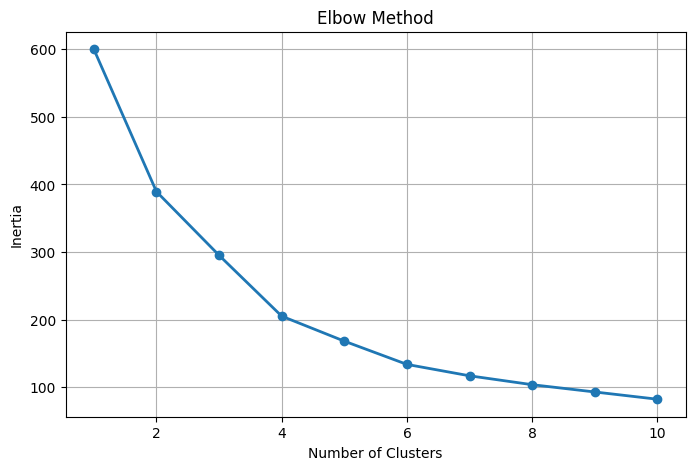

In [25]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker='o',
    linewidth=2
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)

plt.show()

## Applying K-Means Clustering

Based on the Elbow Method, K = 5 is selected and the K-Means model is trained on the scaled dataset.

In [26]:
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


## Cluster Centers

Cluster centers represent the average characteristics of customers within each segment.

In [27]:
centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)

centers_df = pd.DataFrame(
    centers,
    columns=[
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
)

centers_df

,Age,Annual Income (k$),Spending Score (1-100)
0,46.250000,26.750000,18.350000
1,25.185185,41.092593,62.240741
2,32.875000,86.100000,81.525000
3,39.871795,86.102564,19.358974
4,55.638298,54.382979,48.851064


## Visualizing Customer Segments

Customers are visualized according to Annual Income and Spending Score, with cluster centers highlighted.

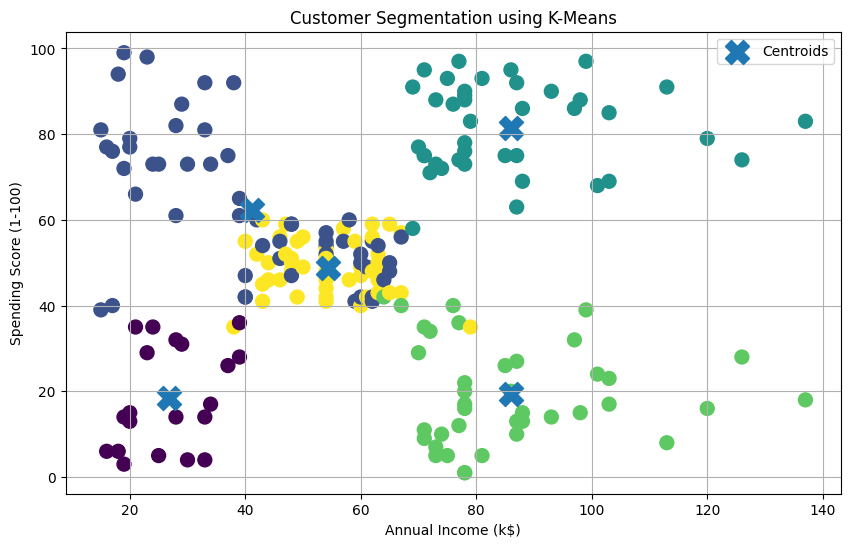

In [28]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    s=100
)

plt.scatter(
    centers[:,1],
    centers[:,2],
    marker='X',
    s=300,
    label='Centroids'
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")

plt.legend()
plt.grid(True)

plt.show()

## Cluster Profile Analysis

The average values of Age, Annual Income, and Spending Score are calculated to understand the characteristics of each customer segment.

In [29]:
cluster_summary = df.groupby("Cluster")[[
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]].mean().round(2)

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.25,26.75,18.35
1,25.19,41.09,62.24
2,32.88,86.10,81.53
3,39.87,86.10,19.36
4,55.64,54.38,48.85


## Cluster Distribution

This section shows the number of customers assigned to each cluster.

In [30]:
df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,20
1,54
2,40
3,39
4,47


## Customer Distribution Across Clusters

The bar chart below shows the number of customers present in each cluster.

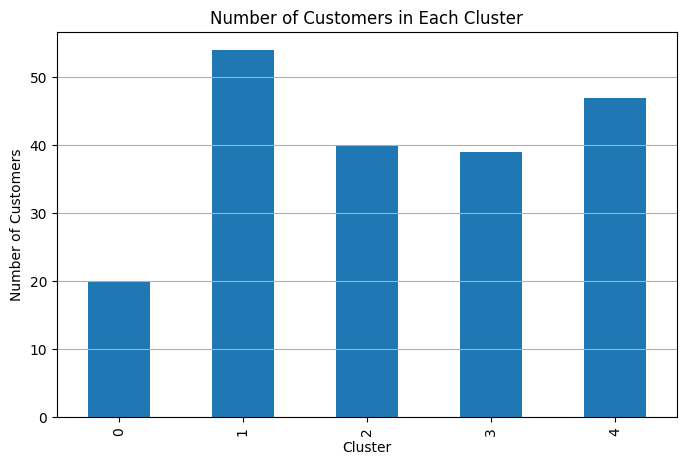

In [31]:
df['Cluster'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.grid(axis='y')

plt.show()

In [32]:
df.to_csv("Customer_Segments.csv", index=False)

print("Clustered dataset saved successfully.")

Clustered dataset saved successfully.


# Conclusion

In this project, K-Means Clustering was successfully applied to segment customers of a retail store.

### Steps Performed

- Loaded and explored the dataset
- Checked for missing values
- Analyzed statistical properties
- Selected relevant features
- Standardized the data
- Determined the optimal number of clusters using the Elbow Method
- Applied K-Means Clustering
- Visualized customer segments and cluster centers
- Performed cluster profile analysis
- Saved the clustered dataset
Cluster Insights

Cluster 0: Customers with low income and low spending scores.
Cluster 1: Young customers with moderate income and moderate spending behavior.

Cluster 2: High-income customers with high spending scores (potential premium customers).

Cluster 3: High-income customers with low spending scores.

Cluster 4: Older customers with moderate income and average spending behavior.

These insights can help businesses create targeted marketing strategies for different customer groups.

### Outcome

The model grouped customers into distinct segments based on age, annual income, and spending behavior. These insights can help businesses understand customer groups and design targeted marketing strategies.